In [21]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('../data/ab-test.csv')

In [23]:
df

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [24]:
df_before = df[df['time'] == 'before']
df_after = df[df['time'] == 'after']

In [25]:
df_before = [df_before[df_before['group'] == 'control']['diff'], df_before[df_before['group'] == 'test']['diff']]
df_after = [df_after[df_after['group'] == 'control']['diff'], df_after[df_after['group'] == 'test']['diff']]

In [26]:
df_after

[14    -75.000000
 16    -81.500000
 18    -32.000000
 20     17.500000
 22    -94.000000
 24    -49.000000
 26   -131.666667
 28   -322.666667
 30    -77.000000
 32     -9.000000
 34   -144.666667
 36   -114.500000
 38   -140.666667
 40    -93.333333
 42   -142.333333
 Name: diff, dtype: float64,
 0    -103.333333
 2     -10.000000
 4     -82.333333
 6     -78.500000
 8    -127.500000
 10   -136.500000
 12   -158.500000
 Name: diff, dtype: float64]

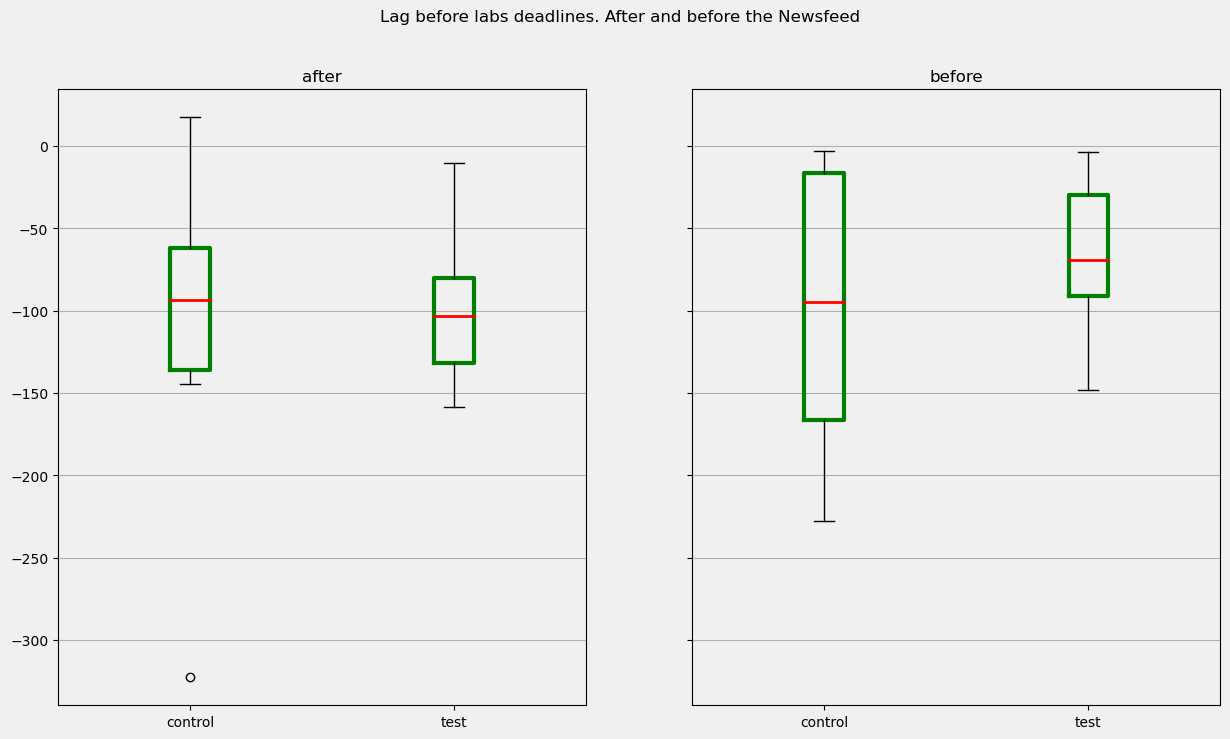

In [27]:
# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
fig.suptitle('Lag before labs deadlines. After and before the Newsfeed')
# After subplot
axes[0].boxplot(df_after, boxprops=dict(color='green', linewidth=3), medianprops=dict(color='red', linewidth=2), flierprops=dict(marker='o', color='black'))
axes[0].set_title('after')
axes[0].set_xticklabels(['control', 'test'])
axes[0].grid(True, axis='y')

# Before subplot
axes[1].boxplot(df_before, boxprops=dict(color='green', linewidth=3), medianprops=dict(color='red', linewidth=2), flierprops=dict(marker='o', color='black'))
axes[1].set_title('before')
axes[1].set_xticklabels(['control', 'test'])
axes[1].grid(True, axis='y')

for ax in axes:
    ax.set_facecolor('#f0f0f0')
fig.set_facecolor('#f0f0f0')

## What was the IQR of the control group before the newsfeed?

In [28]:
q1 = df_before[0].quantile(0.25)
q3 = df_before[0].quantile(0.75)
iqr = q3 - q1
iqr

150.0

Answer: 150.